# ICESat-2 Kd Pipeline - Step-by-Step Walkthrough

This notebook walks through all 19 flowchart steps of the Kd (diffuse attenuation coefficient) pipeline, with intermediate visualizations at each stage.

## NOTES
- this notebook will need to be updated to use the version of the code that gets data from SlideRule

**Reference:** Eidam et al. (2024). *ICESat-2 and ocean particulates: A roadmap for calculating Kd from space-based lidar photon profiles.* Remote Sensing of Environment, Vol. 311.

**Site:** Gulf of Lion, Mediterranean (RGT 1197, 2023-12-06)

In [1]:
import sys; sys.path.insert(0, '/Users/wayne128/Projects/MainProjs/ICESat2_HLS/Kd_ComparisionPaper/PythonScript/ICESat2_kdph-main/icesat-2_kdph_py')
import os
import sys
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

%matplotlib inline
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['figure.dpi'] = 100

# Make sure we import from the pipeline code
sys.path.insert(0, os.path.dirname(os.path.abspath('__file__')))

from kd_utils.data_processing import read_granule, load_data, Extract_sea_photons
from kd_utils.data_processing import apply_optional_ir_ap_filter, apply_optional_solar_background_filter
from kd_utils.data_processing import filter_photon_dataset_by_hull_area
from kd_utils.sea_photons_analysis import process_sea_photon_binning, horizontal_vertical_bin_dataset
from kd_utils.sea_photons_analysis import get_sea_surface_height_adaptive
from kd_utils.bathy_processing import process_subsurface_photon_filtering
from kd_utils.Kd_analysis import process_kd_calculation, find_exponential_decay_zone, fit_beers_law

print('All imports successful!')

All imports successful!


In [2]:
# Configuration — change these paths for your system
WORKSPACE = '/Users/wayne128/Projects/MainProjs/ICESat2_HLS/Kd_ComparisionPaper/'
ATL03_FILE = WORKSPACE + 'TestDriving/ATL03_20231206093744_11972106_007_01_subsetted.h5'
SHORELINE_PATH = WORKSPACE + 'Dataset/Shorelines/ne_10m_land/ne_10m_land.shp'
GEBCO_DIR = WORKSPACE + 'Dataset/Bathy/gebco_2024_geotiff/'

HORIZONTAL_RES = 500   # along-track bin width (meters)
VERTICAL_RES = 0.25    # vertical bin height (meters)
SUBSURFACE_THRESH = 1.0  # depth below surface to start collecting photons

# Site metadata for plot labels
SITE_NAME = 'Gulf of Lion, Mediterranean'
SITE_DATE = '2023-12-06'
SITE_RGT = 'RGT 1197'
PLOT_LABEL = f'{SITE_NAME} | {SITE_DATE} | {SITE_RGT}'

print(f'ATL03 file: {os.path.basename(ATL03_FILE)}')
print(f'Site: {PLOT_LABEL}')
print(f'Resolution: {HORIZONTAL_RES}m x {VERTICAL_RES}m')

ATL03 file: ATL03_20231206093744_11972106_007_01_subsetted.h5
Site: Gulf of Lion, Mediterranean | 2023-12-06 | RGT 1197
Resolution: 500m x 0.25m


---
## Step 1: Acquire ATL03 Data

Load the ICESat-2 ATL03 HDF5 granule. This contains geolocated photon heights for 6 beams (3 pairs of strong/weak). We extract the strong beams for Kd analysis.

In [3]:
# Step 1: Load ATL03 data
is2_mds, is2_attrs, is2_beams = load_data(ATL03_FILE, False)

# Identify strong beams
strong_beams = [
    gtx for gtx in is2_beams
    if is2_attrs[gtx]['atlas_beam_type'].decode('utf-8') == 'strong'
]
target_beams = strong_beams[:1]  # use first strong beam for demo

# Update plot label with GT
GT_LABEL = target_beams[0]
PLOT_LABEL_FULL = f'{SITE_NAME} | {SITE_DATE} | {SITE_RGT} | {GT_LABEL}'

print(f'All beams: {is2_beams}')
print(f'Strong beams: {strong_beams}')
print(f'Target beam: {target_beams}')

# Extract version from filename
version_match = re.search(r'ATL03_\d{14}_\d{8}_(\d{3})_\d{2}', os.path.basename(ATL03_FILE))
atl03_version = int(version_match.group(1)) if version_match else None
print(f'ATL03 version: {atl03_version:03d}')

All beams: ['gt1l', 'gt1r', 'gt2l', 'gt2r', 'gt3l', 'gt3r']
Strong beams: ['gt1r', 'gt2r', 'gt3r']
Target beam: ['gt1r']
ATL03 version: 007


In [4]:
# Extract sea photons (applies shoreline mask to remove land)
sea_photon_dataset = Extract_sea_photons(is2_mds, target_beams, SHORELINE_PATH)

print(f'Total sea photons: {len(sea_photon_dataset):,}')
print(f'Columns: {list(sea_photon_dataset.columns)}')
print(f'\nLat range: {sea_photon_dataset["latitude"].min():.4f} to {sea_photon_dataset["latitude"].max():.4f}')
print(f'Height range: {sea_photon_dataset["photon_height"].min():.1f} to {sea_photon_dataset["photon_height"].max():.1f} m')

Processing strong beam ID: gt1r
Total sea photons: 157,828
Columns: ['latitude', 'longitude', 'lat', 'lon', 'photon_height', 'quality_ph', 'is_land_label', 'photon_conf', 'ref_elevation', 'ref_azimuth', 'relative_AT_dist', 'solar_elevation', 'background_rate', 'beam_id']

Lat range: 43.0256 to 43.4927
Height range: -85.8 to 95.3 m


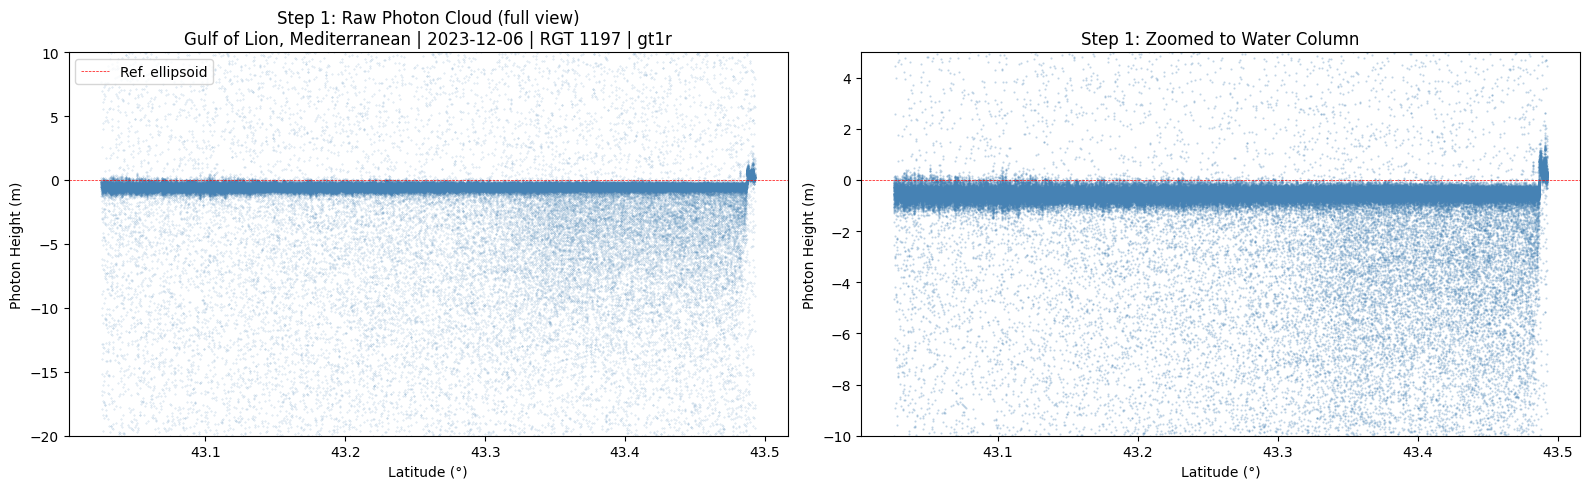

157,828 photons after shoreline masking


In [5]:
# Visualize: Raw photon cloud
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Full view
ax1.scatter(sea_photon_dataset['latitude'], sea_photon_dataset['photon_height'],
           s=0.1, alpha=0.3, c='steelblue')
ax1.set_xlabel('Latitude (°)')
ax1.set_ylabel('Photon Height (m)')
ax1.set_title(f'Step 1: Raw Photon Cloud (full view)\n{PLOT_LABEL_FULL}')
ax1.set_ylim(-20, 10)
ax1.axhline(y=0, color='red', linewidth=0.5, linestyle='--', label='Ref. ellipsoid')
ax1.legend()

# Zoomed view (-10 to 5m)
ax2.scatter(sea_photon_dataset['latitude'], sea_photon_dataset['photon_height'],
           s=0.3, alpha=0.3, c='steelblue')
ax2.set_xlabel('Latitude (°)')
ax2.set_ylabel('Photon Height (m)')
ax2.set_title('Step 1: Zoomed to Water Column')
ax2.set_ylim(-10, 5)
ax2.axhline(y=0, color='red', linewidth=0.5, linestyle='--')

plt.tight_layout()
plt.show()
print(f'{len(sea_photon_dataset):,} photons after shoreline masking')

---
## Step 2: Remove IR/Afterpulse Photons (Optional)

ATL03 v007+ includes quality flags that can identify impulse-response and afterpulse artifacts. These are spurious photon returns from the detector, not real ocean signal.

In [6]:
# Step 2: IR/AP filter (optional — enable to see effect)
ENABLE_IR_AP = False  # Set True to test

n_before = len(sea_photon_dataset)
sea_photon_dataset = apply_optional_ir_ap_filter(
    sea_photon_dataset, enabled=ENABLE_IR_AP, quality_max=0, min_signal_conf=0
)
n_after = len(sea_photon_dataset)

if ENABLE_IR_AP:
    print(f'IR/AP filter: {n_before:,} → {n_after:,} ({n_before - n_after:,} removed, {(n_before-n_after)/n_before*100:.1f}%)')
else:
    print('IR/AP filter: DISABLED (set ENABLE_IR_AP=True to test)')

IR/AP filter: DISABLED (set ENABLE_IR_AP=True to test)


---
## Step 5: Remove Solar Background (Default: ON)

**Theory:** ICESat-2's ATLAS laser (532 nm) fires ~10,000 pulses/sec. During daytime, solar photons at the same wavelength create a background noise floor that scales with sun angle. The solar background filter:

1. Bins photons by solar elevation angle (from ATL03 metadata)
2. Computes a rolling median of the background rate across elevation bins
3. Flags photons where `actual_background > noise_multiplier × expected_background`
4. Removes flagged photons, keeping only those with `photon_conf ≥ min_signal_conf`

**Self-gating:** If `solar_elevation < 6°` (nighttime), the filter skips automatically — no photons removed.

**Why this matters for Kd:** Unfiltered solar noise adds a constant offset to photon counts at all depths, which flattens the Beer's Law decay curve and biases Kd toward zero.

In [7]:
# Step 5: Solar background filter
n_before = len(sea_photon_dataset)
sea_photon_dataset = apply_optional_solar_background_filter(
    sea_photon_dataset, enabled=True,
    day_threshold=6.0, median_window_deg=10.0,
    noise_multiplier=1.5, min_signal_conf=2
)
n_after = len(sea_photon_dataset)
print(f'Solar background filter: {n_before:,} → {n_after:,} ({n_before - n_after:,} removed)')

if 'solar_elevation' in sea_photon_dataset.columns:
    max_solar = sea_photon_dataset['solar_elevation'].max()
    print(f'Max solar elevation: {max_solar:.1f}° ({"daytime" if max_solar > 6 else "nighttime"} pass)')

Solar background filter: 157,828 → 157,439 (389 removed)
Max solar elevation: 19.6° (daytime pass)


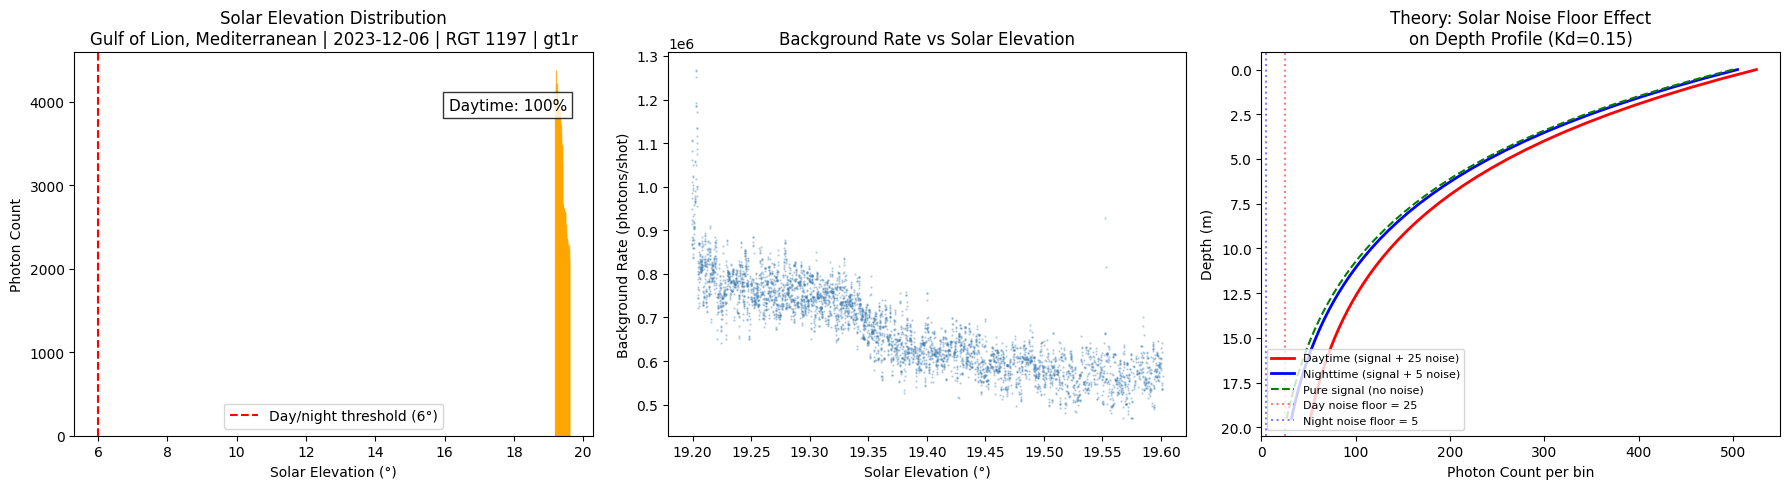

The noise floor raises the baseline photon count at all depths,
which flattens the log-linear slope and biases Kd toward zero.


In [8]:
# Visualize: Solar background analysis
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1: Solar elevation distribution
if 'solar_elevation' in sea_photon_dataset.columns:
    se = sea_photon_dataset['solar_elevation']
    axes[0].hist(se, bins=50, color='gold', edgecolor='orange', alpha=0.8)
    axes[0].axvline(x=6.0, color='red', linestyle='--', label='Day/night threshold (6°)')
    axes[0].set_xlabel('Solar Elevation (°)')
    axes[0].set_ylabel('Photon Count')
    axes[0].set_title(f'Solar Elevation Distribution\n{PLOT_LABEL_FULL}')
    axes[0].legend()
    day_frac = (se > 6).mean() * 100
    axes[0].text(0.95, 0.85, f'Daytime: {day_frac:.0f}%', transform=axes[0].transAxes,
                ha='right', fontsize=11, bbox=dict(facecolor='white', alpha=0.8))
else:
    axes[0].text(0.5, 0.5, 'No solar_elevation data', transform=axes[0].transAxes, ha='center')

# Panel 2: Background rate vs solar elevation
if 'background_rate' in sea_photon_dataset.columns and 'solar_elevation' in sea_photon_dataset.columns:
    sample = sea_photon_dataset.sample(min(5000, len(sea_photon_dataset)), random_state=42)
    axes[1].scatter(sample['solar_elevation'], sample['background_rate'], s=0.5, alpha=0.3, c='steelblue')
    axes[1].set_xlabel('Solar Elevation (°)')
    axes[1].set_ylabel('Background Rate (photons/shot)')
    axes[1].set_title('Background Rate vs Solar Elevation')
else:
    axes[1].text(0.5, 0.5, 'No background_rate data', transform=axes[1].transAxes, ha='center')

# Panel 3: Noise floor depth profile — theory illustration
# Show how solar background creates a constant noise floor at all depths
depth_range = np.arange(0, 20, 0.5)
kd_example = 0.15
signal = 500 * np.exp(-kd_example * depth_range)
noise_day = 25  # typical daytime noise per 0.25m bin
noise_night = 5

axes[2].plot(signal + noise_day, depth_range, 'r-', linewidth=2, label=f'Daytime (signal + {noise_day} noise)')
axes[2].plot(signal + noise_night, depth_range, 'b-', linewidth=2, label=f'Nighttime (signal + {noise_night} noise)')
axes[2].plot(signal, depth_range, 'g--', linewidth=1.5, label='Pure signal (no noise)')
axes[2].axvline(x=noise_day, color='red', linestyle=':', alpha=0.5, label=f'Day noise floor = {noise_day}')
axes[2].axvline(x=noise_night, color='blue', linestyle=':', alpha=0.5, label=f'Night noise floor = {noise_night}')
axes[2].set_xlabel('Photon Count per bin')
axes[2].set_ylabel('Depth (m)')
axes[2].set_title('Theory: Solar Noise Floor Effect\non Depth Profile (Kd=0.15)')
axes[2].invert_yaxis()
axes[2].legend(fontsize=8, loc='lower left')
axes[2].set_xlim(0, 550)

plt.tight_layout()
plt.show()
print('The noise floor raises the baseline photon count at all depths,')
print('which flattens the log-linear slope and biases Kd toward zero.')

---
## Steps 3-4: Bin Photons (Horizontal + Vertical)

Create 2D histogram: along-track bins (default 500m) × depth bins (default 0.25m). This is the foundation for surface detection and Kd fitting.

In [9]:
# Steps 3-4: Binning
binned_dataset = process_sea_photon_binning(
    sea_photon_dataset, horizontal_res=HORIZONTAL_RES, vertical_res=VERTICAL_RES
)

n_lat_bins = binned_dataset['lat_bins'].nunique()
n_height_bins = binned_dataset['height_bins'].nunique()
print(f'Binned dataset: {len(binned_dataset):,} photons')
print(f'Along-track bins: {n_lat_bins} ({HORIZONTAL_RES}m each)')
print(f'Depth bins: {n_height_bins} ({VERTICAL_RES}m each)')

Processing binning for beam: gt1r
Binned dataset: 141,661 photons
Along-track bins: 104 (500m each)
Depth bins: 300 (0.25m each)


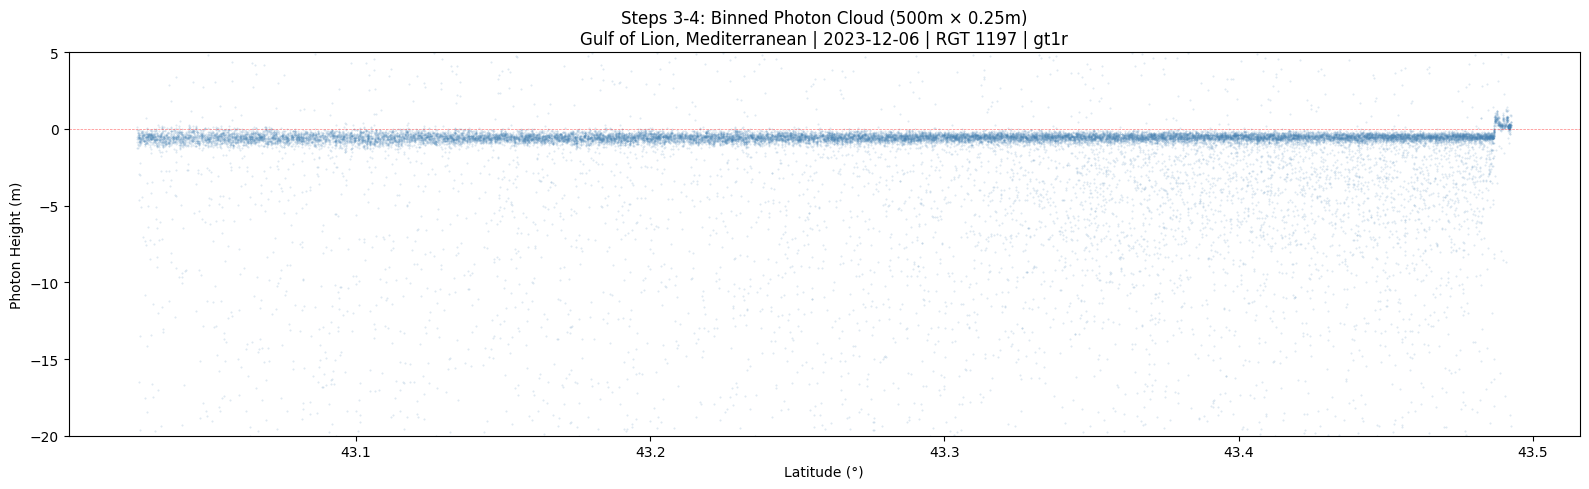

104 along-track bins × 300 depth bins


In [10]:
# Visualize: Binned photon cloud (surface + subsurface visible)
fig, ax = plt.subplots(figsize=(16, 5))
sample = binned_dataset.sample(min(30000, len(binned_dataset)), random_state=42)
ax.scatter(sample['latitude'], sample['photon_height'], s=0.2, alpha=0.2, c='steelblue')
ax.set_xlabel('Latitude (°)')
ax.set_ylabel('Photon Height (m)')
ax.set_title(f'Steps 3-4: Binned Photon Cloud ({HORIZONTAL_RES}m × {VERTICAL_RES}m)\n{PLOT_LABEL_FULL}')
ax.set_ylim(-20, 5)
ax.axhline(y=0, color='red', linewidth=0.5, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()
print(f'{n_lat_bins} along-track bins × {n_height_bins} depth bins')

---
## Step 7: Gaussian Fit for Sea Surface Detection

For each along-track bin, fit a Gaussian curve to the photon height peak to identify:
- **Surface elevation** (mean of Gaussian)
- **Surface roughness σ** (standard deviation — related to wave height)

Photons within 3σ of the surface are removed as "surface returns". Remaining subsurface photons are used for Kd fitting.

In [11]:
# Step 7: Adaptive surface detection
# Returns 4 values: surface heights, abnormal labels, dominated labels, subsurface photons
sea_surface_height, sea_surface_label, _, subsurface_photons = \
    get_sea_surface_height_adaptive(binned_dataset)

# Extract surface info
valid_ssh = [h for h in sea_surface_height if not np.isnan(h)]
print(f'Surface detected in {len(valid_ssh)}/{len(sea_surface_height)} bins')
print(f'Mean sea surface: {np.nanmean(valid_ssh):.3f} m')
print(f'Subsurface photons: {len(subsurface_photons):,}')

Surface detected in 102/104 bins
Mean sea surface: -0.570 m
Subsurface photons: 33,865


Surface σ range: 0.204 - 0.336 m
Bins with σ > 0.5m: 0/102


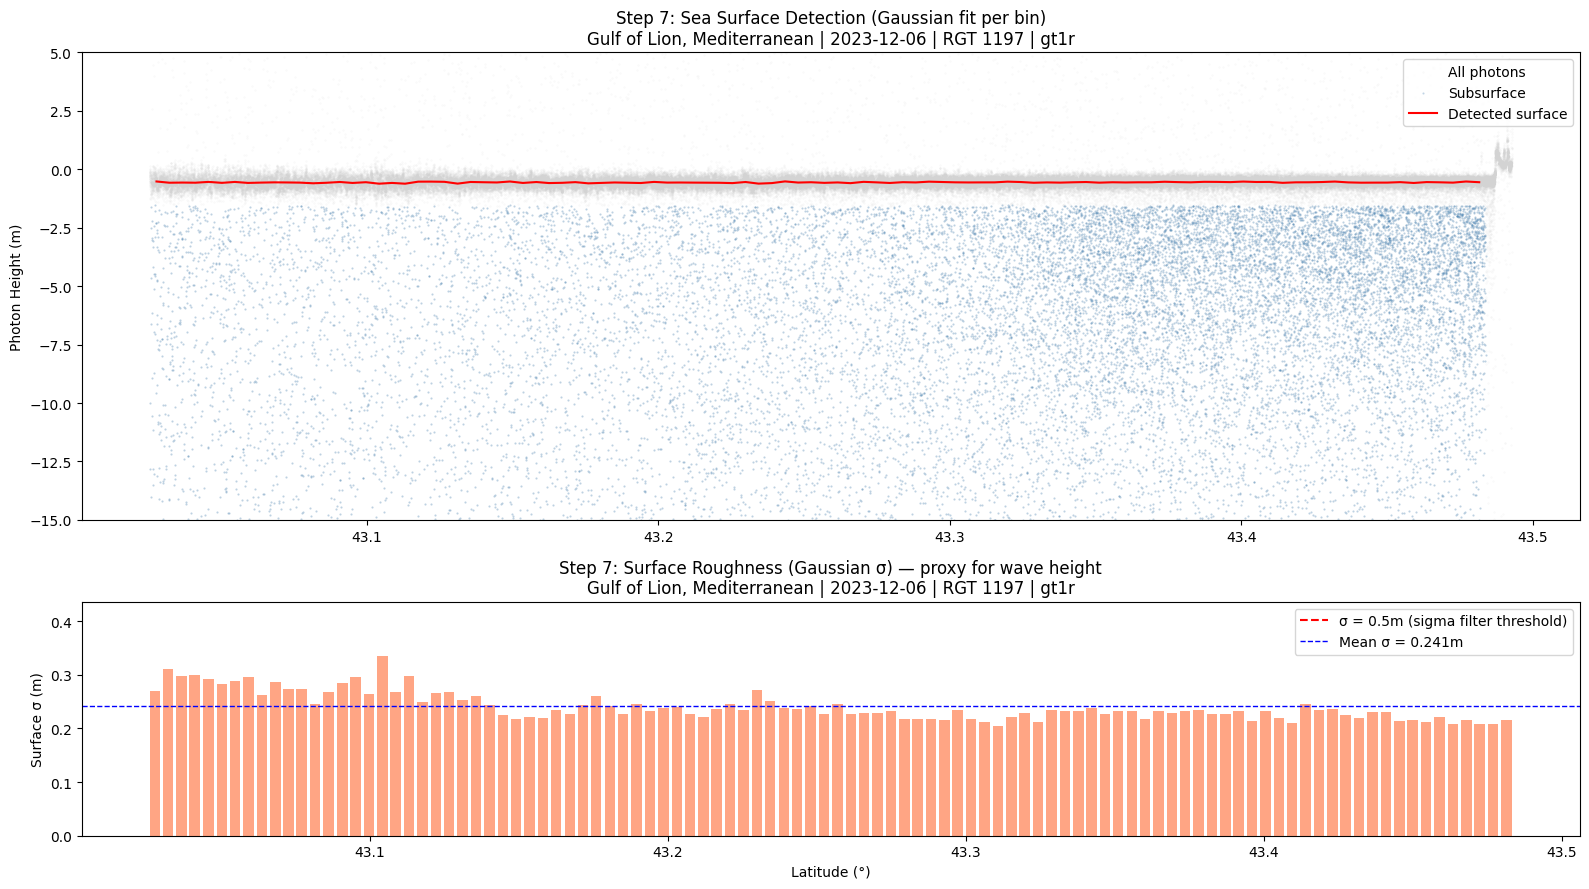

In [12]:
# Visualize: Surface detection + subsurface photons + wave roughness
from kd_utils.bathy_processing import compute_surface_sigma

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 9), gridspec_kw={'height_ratios': [2, 1]})

# Top: Photon cloud with surface line
ax1.scatter(binned_dataset['latitude'], binned_dataset['photon_height'],
           s=0.1, alpha=0.2, c='lightgray', label='All photons')
if not subsurface_photons.empty:
    ax1.scatter(subsurface_photons['latitude'], subsurface_photons['photon_height'],
               s=0.3, alpha=0.3, c='steelblue', label='Subsurface')

# Plot detected surface
lat_bin_centers = binned_dataset.groupby('lat_bins', observed=False)['latitude'].mean()
valid_idx = [i for i, h in enumerate(sea_surface_height) if not np.isnan(h)]
if valid_idx:
    ssh_lats = [lat_bin_centers.iloc[i] for i in valid_idx if i < len(lat_bin_centers)]
    ssh_vals = [sea_surface_height[i] for i in valid_idx]
    ax1.plot(ssh_lats[:len(ssh_vals)], ssh_vals[:len(ssh_lats)], 'r-', linewidth=1.5, label='Detected surface')

ax1.set_ylabel('Photon Height (m)')
ax1.set_ylim(-15, 5)
ax1.set_title(f'Step 7: Sea Surface Detection (Gaussian fit per bin)\n{PLOT_LABEL_FULL}')
ax1.legend(loc='upper right')

# Bottom: Compute surface sigma (wave roughness) per bin
# compute_surface_sigma returns a dict {lat_bin: sigma}
sigma_map = compute_surface_sigma(binned_dataset, sea_surface_height)
if sigma_map:
    sigma_bins = sorted(sigma_map.keys())
    sigma_vals = [sigma_map[b] for b in sigma_bins]
    sigma_lats = [float(lat_bin_centers.iloc[int(b)]) for b in sigma_bins
                  if int(b) < len(lat_bin_centers)]
    sigma_vals = sigma_vals[:len(sigma_lats)]
    
    colors = ['coral' if s <= 0.5 else 'red' for s in sigma_vals]
    bar_width = (sigma_lats[1] - sigma_lats[0]) * 0.8 if len(sigma_lats) > 1 else 0.002
    ax2.bar(sigma_lats, sigma_vals, width=bar_width, color=colors, alpha=0.7, edgecolor='none')
    ax2.axhline(y=0.5, color='red', linestyle='--', linewidth=1.5, label='σ = 0.5m (sigma filter threshold)')
    ax2.axhline(y=np.nanmean(sigma_vals), color='blue', linestyle='--', linewidth=1,
               label=f'Mean σ = {np.nanmean(sigma_vals):.3f}m')
    ax2.set_ylim(0, max(sigma_vals) * 1.3)
    print(f'Surface σ range: {np.nanmin(sigma_vals):.3f} - {np.nanmax(sigma_vals):.3f} m')
    print(f'Bins with σ > 0.5m: {sum(1 for s in sigma_vals if s > 0.5)}/{len(sigma_vals)}')
else:
    ax2.text(0.5, 0.5, 'No sigma values computed', transform=ax2.transAxes,
            ha='center', fontsize=14, color='gray')

ax2.set_ylabel('Surface σ (m)')
ax2.set_xlabel('Latitude (°)')
ax2.set_title(f'Step 7: Surface Roughness (Gaussian σ) — proxy for wave height\n{PLOT_LABEL_FULL}')
ax2.legend()

plt.tight_layout()
plt.show()

---
## Steps 6, 8-14: Subsurface Filtering Chain

**Adaptive Step 6** (new) performs three-level quality assessment:

1. **Per-bin S/N gate**: Compare subsurface photon count at 1-2m to noise floor at 15-20m. If S/N < 3, reject as "insufficient signal" (water too clear for Kd estimation).
2. **Adaptive depth limit**: For passing bins, find the deepest 1m coarse bin where photon count exceeds 2× the noise floor. Photons below this depth are trimmed (noise removal).
3. **Track-level gate**: If >40% of bins rejected, flag the entire track as "insufficient particle load" (e.g., oligotrophic open ocean like Hawaii).

Additional optional filters: surface sigma (Step 8), refraction correction (Steps 9-10), GEBCO/ATL24 bathymetry (Steps 11-13), and sea surface flattening (Step 14).

In [13]:
# Steps 6-14: Full subsurface filtering with adaptive Step 6
import glob
gebco_paths = glob.glob(os.path.join(GEBCO_DIR, 'gebco_*.tif'))

# Run subsurface filtering with adaptive histogram quality filter ENABLED
ssh_out, ssl_out, filtered_subsurface = process_subsurface_photon_filtering(
    binned_dataset,
    gebco_paths,
    SUBSURFACE_THRESH,
    -6,
    use_gebco_filter=False,
    use_atl24_filter=False,
    apply_histogram_quality_filter=True,   # Adaptive Step 6 enabled
    apply_surface_sigma_filter=False,
    apply_refraction_correction=False,
    apply_post_refraction_refit=False,
    apply_flattening=False,
    horizontal_res=HORIZONTAL_RES,
    vertical_res=VERTICAL_RES,
)

# Filter to target beams
final_subsurface = filtered_subsurface[
    filtered_subsurface['beam_id'].isin(target_beams)
].copy()

if final_subsurface.empty:
    print(f'⚠ ALL BINS REJECTED — track flagged as insufficient particle load')
    print(f'  This site may be too clear for photon-profile Kd estimation.')
else:
    print(f'Subsurface photons after adaptive filtering: {len(final_subsurface):,}')
    print(f'Depth range: {final_subsurface["photon_height"].min():.1f} to {final_subsurface["photon_height"].max():.1f} m')

# Also compute adaptive depth limits separately for visualization
from kd_utils.bathy_processing import apply_optional_histogram_quality_filter
# We need the depth limits for plotting — recompute on binned data per beam
_depth_limits = {}
for beam_id, beam_data in binned_dataset.groupby('beam_id'):
    if beam_id not in target_beams:
        continue
    _ssh, _ssl, _, _ = get_sea_surface_height_adaptive(beam_data)
    _lat_keys = list(beam_data.groupby('lat_bins', observed=False).groups.keys())
    for i, lk in enumerate(_lat_keys):
        if i >= len(_ssh) or np.isnan(_ssh[i]):
            continue
        surface = _ssh[i]
        bd = beam_data[beam_data['lat_bins'] == lk]
        depth = surface - bd['photon_height'].values
        depth = depth[depth > 0]
        if len(depth) < 10:
            continue
        counts, _ = np.histogram(depth, bins=np.arange(0, 21, 1))
        if len(counts) < 5:
            continue
        noise = max(float(np.median(counts[-5:])), 0.5)
        ref = float(counts[1]) if len(counts) > 1 else 0
        if ref / noise < 3.0:
            continue
        thresh = noise * 2.0
        sd = 3.0
        centers = np.arange(0.5, 20, 1)[:len(counts)]
        for j in range(len(counts)):
            if counts[j] > thresh:
                sd = centers[j] + 0.5
        _depth_limits[lk] = max(3.0, min(sd, 20.0))

if _depth_limits:
    avg_dl = np.mean(list(_depth_limits.values()))
    print(f'Adaptive depth limits: avg {avg_dl:.1f}m (range {min(_depth_limits.values()):.0f}-{max(_depth_limits.values()):.0f}m)')
    print(f'Bins with depth limit: {len(_depth_limits)}')

Processing subsurface filtering for beam: gt1r


Subsurface photons after adaptive filtering: 14,485
Depth range: -19.8 to -1.5 m


Adaptive depth limits: avg 12.3m (range 3-20m)
Bins with depth limit: 80


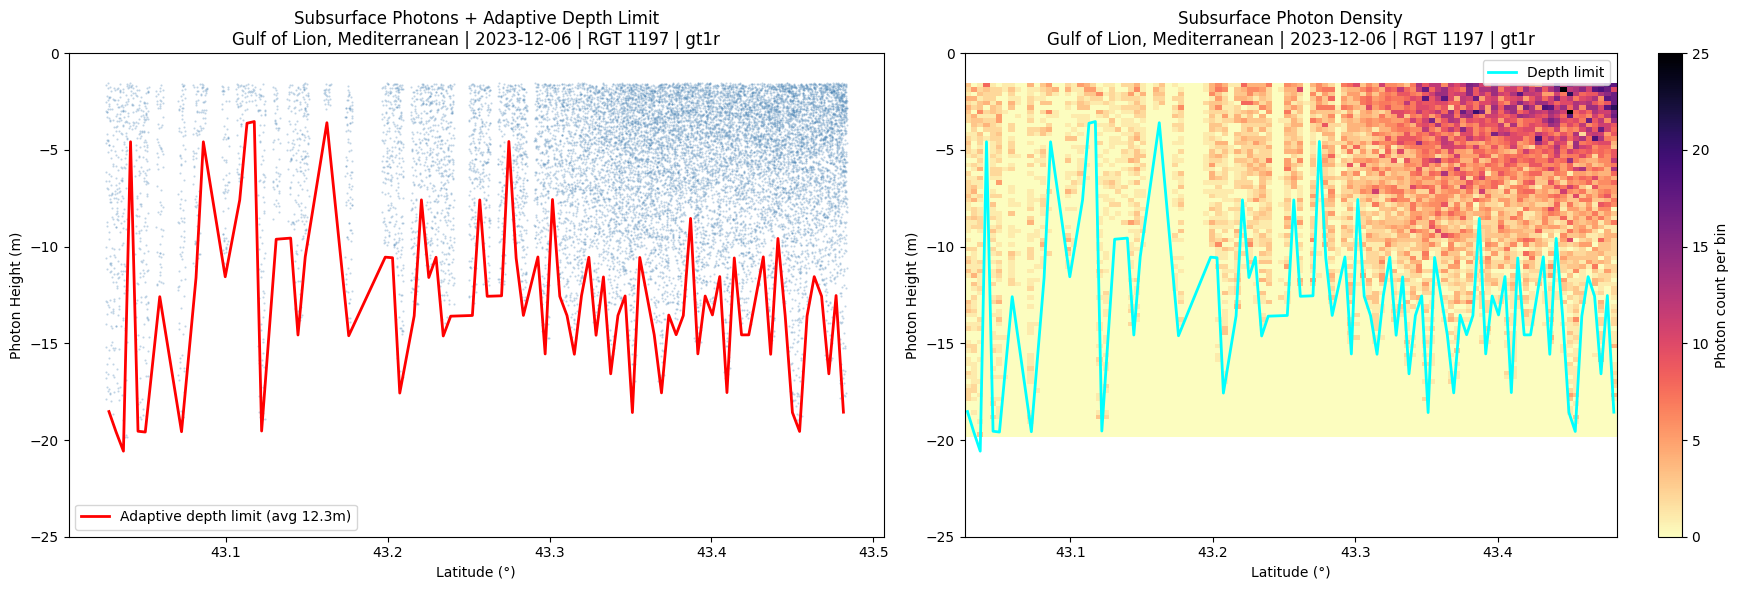

Subsurface photons: 14,485


In [14]:
# Visualize: Subsurface photons + adaptive depth limit overlay
if final_subsurface.empty:
    print('No subsurface photons — track was rejected. Skipping plot.')
else:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

    # Left: Scatter with adaptive depth limit line
    ax1.scatter(final_subsurface['latitude'], final_subsurface['photon_height'],
              s=0.3, alpha=0.3, c='steelblue')
    
    # Overlay adaptive depth limits as a red line
    if _depth_limits:
        dl_lat_bins = sorted(_depth_limits.keys())
        dl_lats = []
        dl_heights = []
        lat_bin_centers_all = binned_dataset.groupby('lat_bins', observed=False)['latitude'].mean()
        for lb in dl_lat_bins:
            idx = int(lb) if not np.isnan(lb) else -1
            if 0 <= idx < len(lat_bin_centers_all):
                dl_lats.append(float(lat_bin_centers_all.iloc[idx]))
                # Depth limit is below surface — convert to photon_height
                ssh_idx = idx if idx < len(sea_surface_height) else -1
                if ssh_idx >= 0 and not np.isnan(sea_surface_height[ssh_idx]):
                    dl_heights.append(sea_surface_height[ssh_idx] - _depth_limits[lb])
                else:
                    dl_heights.append(-_depth_limits[lb])
        if dl_lats:
            ax1.plot(dl_lats, dl_heights, 'r-', linewidth=2, label=f'Adaptive depth limit (avg {avg_dl:.1f}m)')
            ax1.legend(fontsize=10)
    
    ax1.set_xlabel('Latitude (°)')
    ax1.set_ylabel('Photon Height (m)')
    ax1.set_title(f'Subsurface Photons + Adaptive Depth Limit\n{PLOT_LABEL_FULL}')
    ax1.set_ylim(-25, 0)

    # Right: 2D density heatmap
    lat_vals = final_subsurface['latitude'].values
    h_vals = final_subsurface['photon_height'].values
    hist2d, xedges, yedges = np.histogram2d(lat_vals, h_vals, bins=[n_lat_bins, 80])
    im = ax2.pcolormesh(xedges, yedges, hist2d.T, cmap='magma_r', shading='auto')
    
    # Also overlay depth limit on heatmap
    if dl_lats:
        ax2.plot(dl_lats, dl_heights, 'cyan', linewidth=2, label='Depth limit')
        ax2.legend(fontsize=10)
    
    ax2.set_xlabel('Latitude (°)')
    ax2.set_ylabel('Photon Height (m)')
    ax2.set_title(f'Subsurface Photon Density\n{PLOT_LABEL_FULL}')
    ax2.set_ylim(-25, 0)
    plt.colorbar(im, ax=ax2, label='Photon count per bin')

    plt.tight_layout()
    plt.show()
    print(f'Subsurface photons: {len(final_subsurface):,}')

---
## Steps 16-17: Kd Calculation (Beer's Law Fit)

For each along-track bin:
1. **Step 16**: Build depth histogram, find the exponential decay zone
2. **Step 17**: Fit Beer's Law: `log(photon_count) = log(E₀) - Kd × depth`

The **hybrid** method (new default) uses BIC-stabilised breakpoint detection to automatically separate signal from noise, then fits only the decay segment.

In [15]:
# Steps 16-17: Kd calculation
if final_subsurface.empty:
    print('⚠ No subsurface photons — Kd calculation skipped (track rejected).')
    kd_results = pd.DataFrame(columns=['lat_bins','kd','e0','noise_floor','surface_sigma','latitude','longitude'])
    valid_kd = kd_results
else:
    kd_results = process_kd_calculation(
        final_subsurface,
        decay_zone_threshold=0.0,
        kd_fit_method='hybrid',
        wave_exclusion_multiplier=0.0,
        wave_sigma_calm_threshold=0.1,
    )
    valid_kd = kd_results.dropna(subset=['kd'])
    valid_kd = valid_kd[valid_kd['kd'] > 0]

    print(f'Kd results: {len(valid_kd)} valid bins out of {len(kd_results)} total')
    print(f'Kd range: {valid_kd["kd"].min():.4f} to {valid_kd["kd"].max():.4f} m⁻¹')
    print(f'Mean Kd: {valid_kd["kd"].mean():.4f} m⁻¹')

Kd results: 70 valid bins out of 104 total
Kd range: 0.0010 to 0.3738 m⁻¹
Mean Kd: 0.1302 m⁻¹


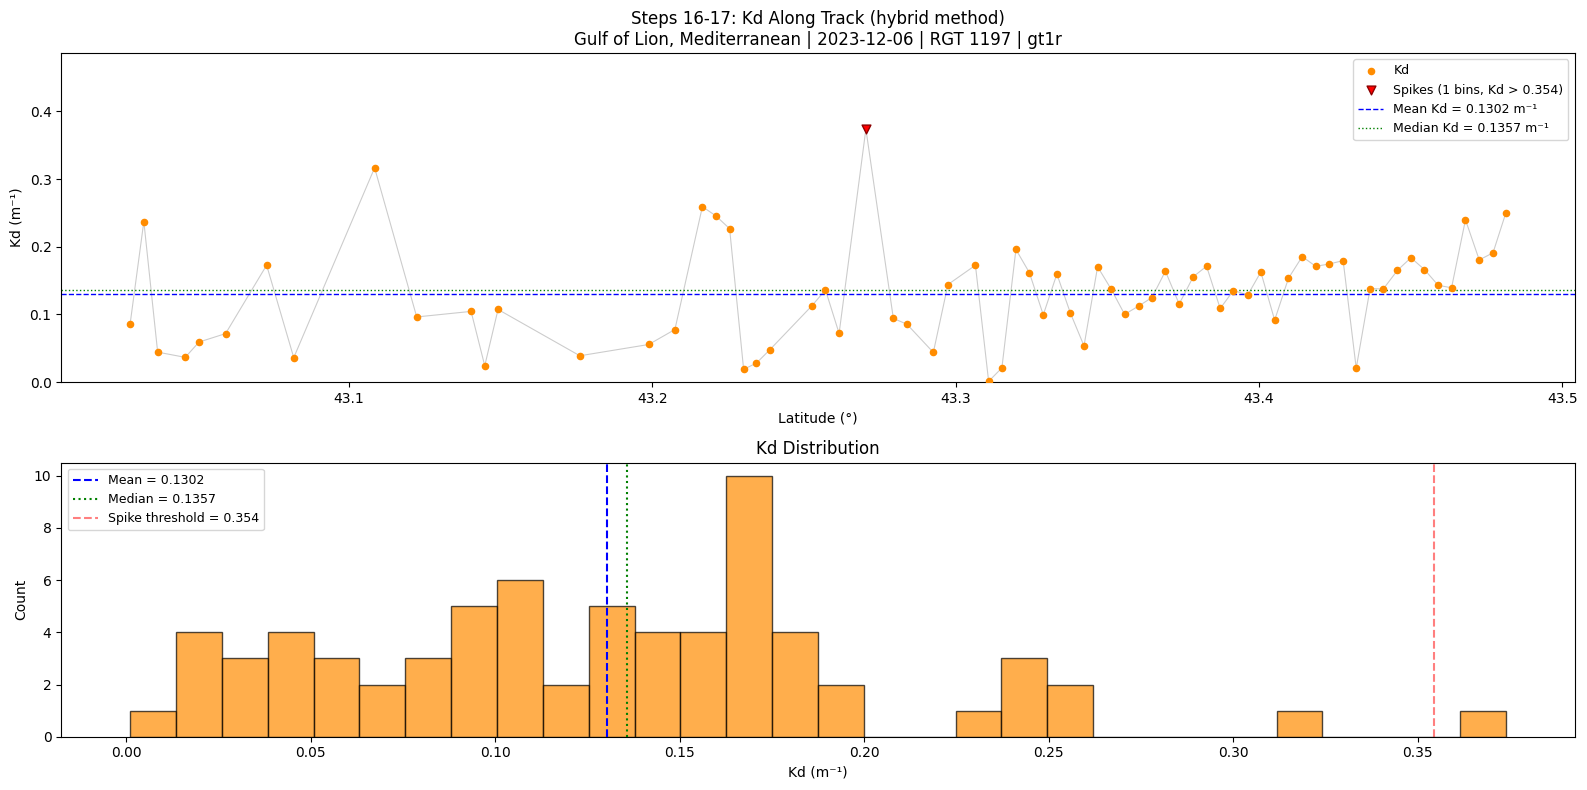

Kd spikes (>0.354): 1 of 70 bins


In [16]:
# Visualize: Kd along track — with spike detection
if valid_kd.empty:
    print('⚠ No valid Kd values — track was rejected or all bins failed fitting.')
    print('  This is expected for oligotrophic water (e.g., Hawaii) where particle')
    print('  load is too low for photon-profile Kd estimation.')
else:
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 8), gridspec_kw={'height_ratios': [1.2, 1]})

    # Detect spikes
    q1, q3 = valid_kd['kd'].quantile(0.25), valid_kd['kd'].quantile(0.75)
    iqr = q3 - q1
    spike_threshold = q3 + 2 * iqr
    is_spike = valid_kd['kd'] > spike_threshold
    normal = valid_kd[~is_spike]
    spikes = valid_kd[is_spike]
    lat_col = 'latitude' if 'latitude' in valid_kd.columns else 'lat_bins'

    ax1.scatter(normal[lat_col], normal['kd'], c='darkorange', s=20, zorder=5, label='Kd')
    ax1.plot(valid_kd[lat_col], valid_kd['kd'], 'k-', alpha=0.2, linewidth=0.8)
    if len(spikes) > 0:
        ax1.scatter(spikes[lat_col], spikes['kd'], c='red', s=40, zorder=6,
                   marker='v', edgecolors='darkred', label=f'Spikes ({len(spikes)} bins, Kd > {spike_threshold:.3f})')
    ax1.axhline(y=valid_kd['kd'].mean(), color='blue', linestyle='--', linewidth=1,
               label=f'Mean Kd = {valid_kd["kd"].mean():.4f} m⁻¹')
    ax1.axhline(y=valid_kd['kd'].median(), color='green', linestyle=':', linewidth=1,
               label=f'Median Kd = {valid_kd["kd"].median():.4f} m⁻¹')
    ax1.set_ylabel('Kd (m⁻¹)')
    ax1.set_title(f'Steps 16-17: Kd Along Track (hybrid method)\n{PLOT_LABEL_FULL}')
    ax1.legend(fontsize=9, loc='upper right')
    ax1.set_ylim(0, min(valid_kd['kd'].max() * 1.3, 2.0))
    ax1.set_xlabel('Latitude (°)')

    ax2.hist(valid_kd['kd'], bins=30, color='darkorange', alpha=0.7, edgecolor='black')
    ax2.axvline(x=valid_kd['kd'].mean(), color='blue', linestyle='--',
               label=f'Mean = {valid_kd["kd"].mean():.4f}')
    ax2.axvline(x=valid_kd['kd'].median(), color='green', linestyle=':',
               label=f'Median = {valid_kd["kd"].median():.4f}')
    if spike_threshold < valid_kd['kd'].max():
        ax2.axvline(x=spike_threshold, color='red', linestyle='--', alpha=0.5,
                   label=f'Spike threshold = {spike_threshold:.3f}')
    ax2.set_xlabel('Kd (m⁻¹)')
    ax2.set_ylabel('Count')
    ax2.set_title('Kd Distribution')
    ax2.legend(fontsize=9)

    plt.tight_layout()
    plt.show()
    print(f'Kd spikes (>{spike_threshold:.3f}): {len(spikes)} of {len(valid_kd)} bins')

---
## Deep Dive: Single Bin — Hybrid vs Log-Linear

This is the core of our method improvement. For a single along-track bin, we show:
1. **The raw depth histogram** — photon counts vs depth
2. **The signal/noise problem** — log-linear fits everything (wrong), hybrid finds the breakpoint (correct)
3. **BIC model selection** — how the algorithm picks the optimal breakpoint depth

In [17]:
# Pick a bin where hybrid FOUND a breakpoint (noise_floor is not NaN)
if valid_kd.empty:
    print('⚠ No valid Kd — deep dive skipped.')
    has_breakpoint = False
else:
    bins_with_bp = valid_kd.dropna(subset=['noise_floor'])
    bins_with_bp = bins_with_bp[bins_with_bp['noise_floor'] > 0]

    if len(bins_with_bp) > 0:
        median_kd = bins_with_bp['kd'].median()
        best_bin_idx = (bins_with_bp['kd'] - median_kd).abs().idxmin()
    else:
        median_kd = valid_kd['kd'].median()
        best_bin_idx = (valid_kd['kd'] - median_kd).abs().idxmin()

    best_bin = valid_kd.loc[best_bin_idx, 'lat_bins']
    hybrid_kd = valid_kd.loc[best_bin_idx, 'kd']
    hybrid_nf = valid_kd.loc[best_bin_idx, 'noise_floor'] if 'noise_floor' in valid_kd.columns else np.nan

    bin_photons = final_subsurface[final_subsurface['lat_bins'] == best_bin].copy()
    if 'sea_surface_height' in bin_photons.columns and not bin_photons['sea_surface_height'].isna().all():
        surface_h = bin_photons['sea_surface_height'].iloc[0]
        bin_photons['depth'] = surface_h - bin_photons['photon_height']
    else:
        bin_photons['depth'] = -bin_photons['photon_height']

    depth_bins_arr = np.arange(0, bin_photons['depth'].max() + VERTICAL_RES, VERTICAL_RES)
    hist_counts, hist_edges = np.histogram(bin_photons['depth'], bins=depth_bins_arr)
    hist_centers = (hist_edges[:-1] + hist_edges[1:]) / 2

    has_breakpoint = not np.isnan(hybrid_nf) and hybrid_nf > 0
    print(f'Selected bin: {best_bin}')
    print(f'Hybrid Kd = {hybrid_kd:.4f} m⁻¹ | Noise floor = {hybrid_nf:.1f} photons')
    print(f'Photons: {len(bin_photons)} | Depth range: {bin_photons["depth"].min():.1f} to {bin_photons["depth"].max():.1f} m')
    print(f'Breakpoint detected: {has_breakpoint}')

Selected bin: 91.0
Hybrid Kd = 0.1382 m⁻¹ | Noise floor = 2.3 photons
Photons: 328 | Depth range: 1.6 to 15.0 m
Breakpoint detected: True


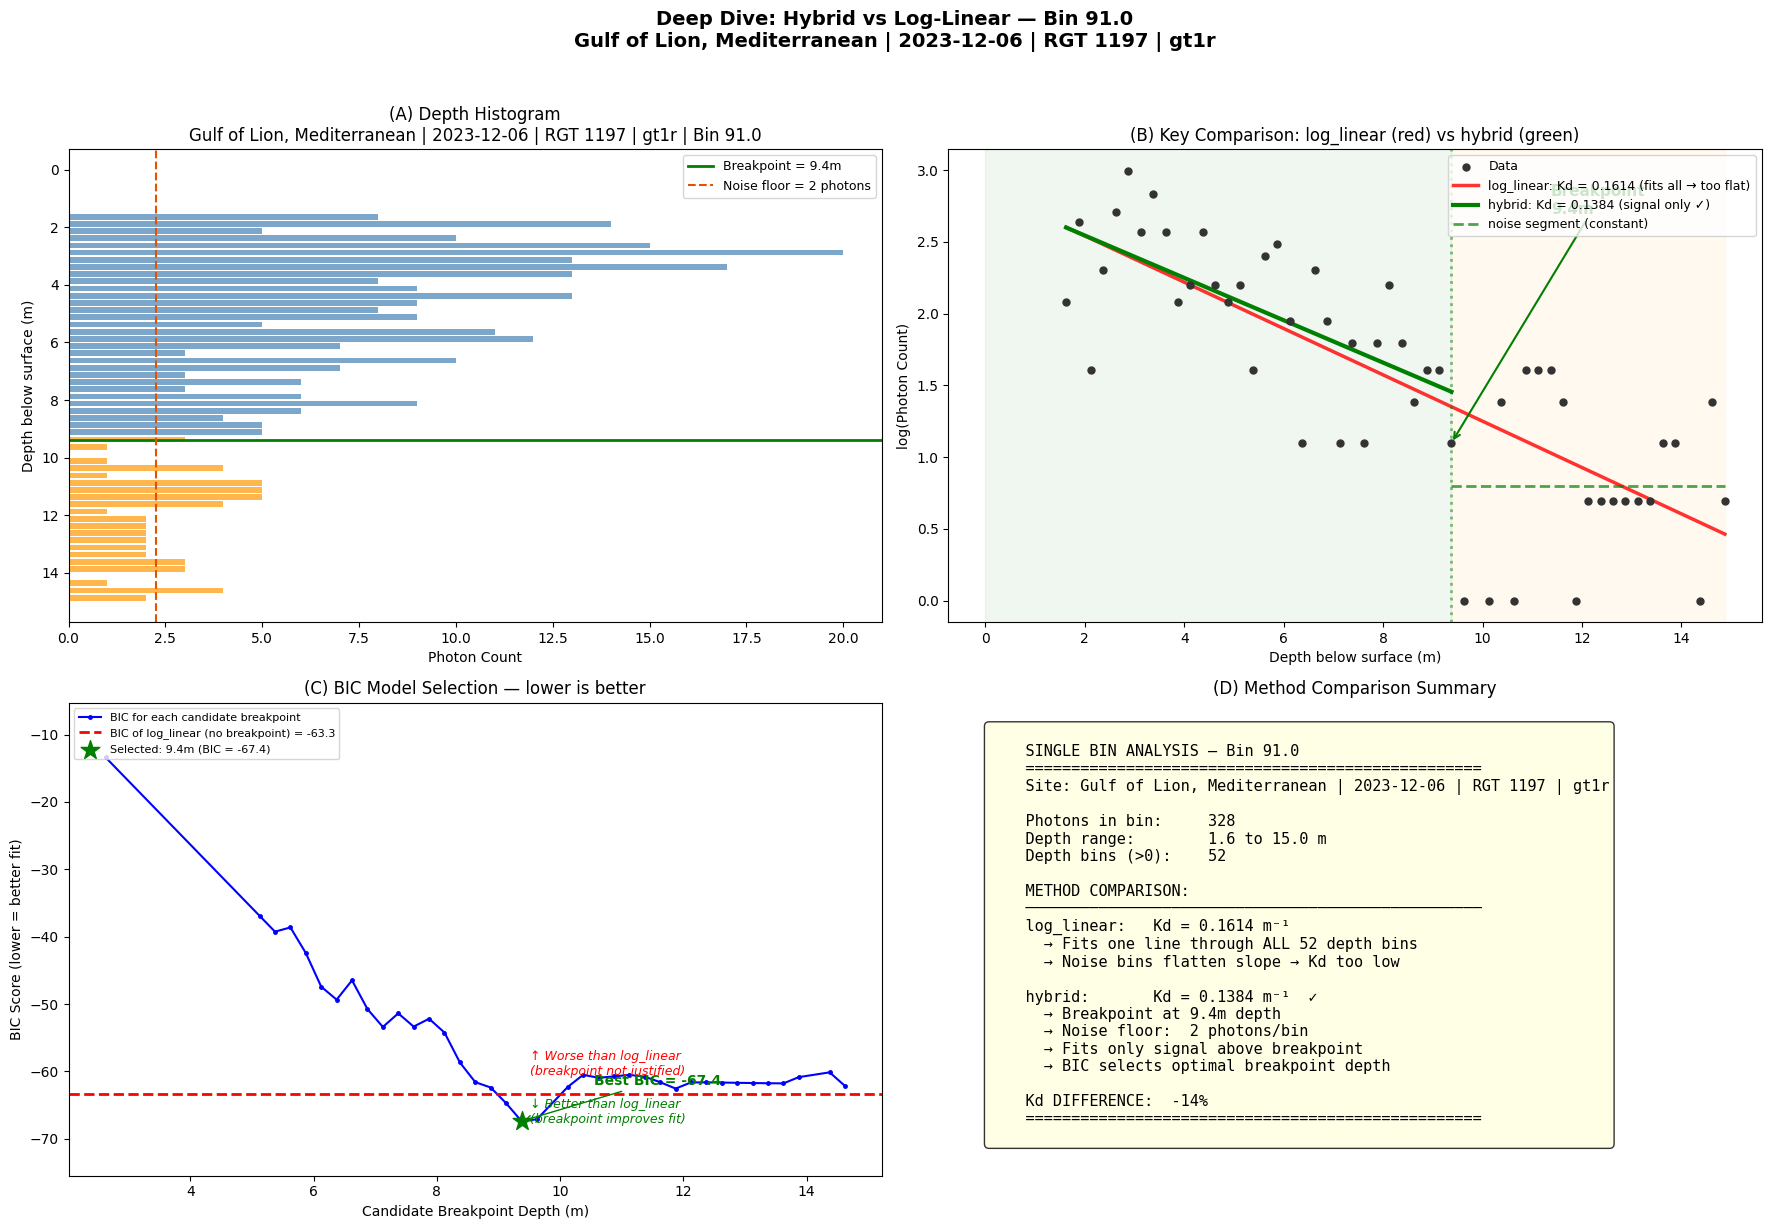

In [18]:
if not valid_kd.empty:
    from sklearn.linear_model import LinearRegression
    from kd_utils.Kd_analysis import fit_beers_law_hybrid, fit_beers_law
    
    # Prepare histogram dataframe
    hist_df = pd.DataFrame({'zdepth': hist_centers, 'photon_counts': hist_counts})
    valid_hist = hist_df[hist_df['photon_counts'] > 0].copy()
    valid_hist['log_counts'] = np.log(valid_hist['photon_counts'])
    
    # --- Run both methods ---
    log_kd, log_e0 = fit_beers_law(valid_hist.rename(columns={'log_counts': 'log_photon_counts'}))
    hyb_kd, hyb_e0, bp_depth, noise_floor = fit_beers_law_hybrid(hist_df)
    
    has_bp = not np.isnan(bp_depth)
    nf_val = noise_floor if not np.isnan(noise_floor) else 0
    
    # =====================================================================
    # FIGURE: 4-panel deep dive
    # =====================================================================
    fig, axes = plt.subplots(2, 2, figsize=(18, 12))
    
    # --- Panel A: Depth histogram colored by signal vs noise ---
    ax = axes[0, 0]
    if has_bp:
        bar_colors = ['steelblue' if d < bp_depth else '#ff9800' for d in hist_centers]
    else:
        bar_colors = ['steelblue'] * len(hist_centers)
    ax.barh(hist_centers, hist_counts, height=VERTICAL_RES*0.8, color=bar_colors, alpha=0.7)
    if has_bp:
        ax.axhline(y=bp_depth, color='green', linewidth=2, linestyle='-',
                  label=f'Breakpoint = {bp_depth:.1f}m')
        ax.axvline(x=nf_val, color='#e65100', linestyle='--', linewidth=1.5,
                  label=f'Noise floor = {nf_val:.0f} photons')
    ax.set_ylabel('Depth below surface (m)')
    ax.set_xlabel('Photon Count')
    ax.set_title(f'(A) Depth Histogram\n{PLOT_LABEL_FULL} | Bin {best_bin}')
    ax.invert_yaxis()
    ax.legend(fontsize=9)
    
    # --- Panel B: THE KEY COMPARISON ---
    ax = axes[0, 1]
    ax.scatter(valid_hist['zdepth'], valid_hist['log_counts'], c='#333', s=25, zorder=5, label='Data')
    depths_arr = valid_hist['zdepth'].values
    
    # Log-linear fit (single line through ALL data — the WRONG approach)
    if not np.isnan(log_kd):
        model_ll = LinearRegression()
        model_ll.fit(depths_arr.reshape(-1, 1), valid_hist['log_counts'].values)
        ll_pred = model_ll.predict(depths_arr.reshape(-1, 1))
        ax.plot(depths_arr, ll_pred, 'r-', linewidth=2.5, alpha=0.8,
               label=f'log_linear: Kd = {log_kd:.4f} (fits all → too flat)')
    
    # Hybrid fit (fits ONLY decay segment above breakpoint — the CORRECT approach)
    if has_bp:
        signal_mask = valid_hist['zdepth'] <= bp_depth
        noise_mask = valid_hist['zdepth'] > bp_depth
    
        # Fit decay segment
        sig_depths = valid_hist.loc[signal_mask, 'zdepth'].values
        sig_log = valid_hist.loc[signal_mask, 'log_counts'].values
        if len(sig_depths) >= 2:
            model_hyb = LinearRegression()
            model_hyb.fit(sig_depths.reshape(-1, 1), sig_log)
            x_decay = np.linspace(sig_depths.min(), bp_depth, 50)
            y_decay = model_hyb.predict(x_decay.reshape(-1, 1))
            ax.plot(x_decay, y_decay, 'g-', linewidth=3,
                   label=f'hybrid: Kd = {hyb_kd:.4f} (signal only ✓)')
    
        # Noise segment (flat constant)
        noise_depths = valid_hist.loc[noise_mask, 'zdepth'].values
        if len(noise_depths) > 0:
            noise_log_mean = valid_hist.loc[noise_mask, 'log_counts'].mean()
            ax.plot([bp_depth, depths_arr.max()], [noise_log_mean, noise_log_mean],
                   'g--', linewidth=2, alpha=0.7, label='noise segment (constant)')
    
        # Breakpoint annotation
        ax.axvline(x=bp_depth, color='green', linestyle=':', linewidth=2, alpha=0.5)
        bp_y = valid_hist.loc[signal_mask, 'log_counts'].iloc[-1] if signal_mask.any() else valid_hist['log_counts'].median()
        ax.annotate(f'Breakpoint\n{bp_depth:.1f}m',
                   xy=(bp_depth, bp_y), xytext=(bp_depth + 2, valid_hist['log_counts'].max() - 0.3),
                   fontsize=11, fontweight='bold', color='green',
                   arrowprops=dict(arrowstyle='->', color='green', lw=1.5))
    
        # Shade regimes
        ax.axvspan(0, bp_depth, alpha=0.06, color='green')
        ax.axvspan(bp_depth, depths_arr.max(), alpha=0.06, color='orange')
    else:
        ax.text(0.5, 0.1, 'No breakpoint found — hybrid fell back to log-linear for this bin',
               transform=ax.transAxes, ha='center', fontsize=10, color='gray', style='italic')
    
    ax.set_xlabel('Depth below surface (m)')
    ax.set_ylabel('log(Photon Count)')
    ax.set_title('(B) Key Comparison: log_linear (red) vs hybrid (green)')
    ax.legend(fontsize=9, loc='upper right')
    
    # --- Panel C: BIC scores ---
    ax = axes[1, 0]
    
    df_bic = hist_df[hist_df['photon_counts'] > 0].copy().sort_values('zdepth')
    df_bic['log_counts'] = np.log(df_bic['photon_counts'])
    bic_depths_list, bic_vals_list = [], []
    n = len(df_bic)
    depths_bic = df_bic['zdepth'].values
    log_c_bic = df_bic['log_counts'].values
    
    # BIC for single-line model (the baseline to beat)
    model_ref = LinearRegression()
    model_ref.fit(depths_bic.reshape(-1, 1), log_c_bic)
    rss_ref = float(np.sum((model_ref.predict(depths_bic.reshape(-1, 1)) - log_c_bic) ** 2))
    bic_ref = n * np.log(rss_ref / n + 1e-10) + 2 * np.log(n)
    
    for bp_i in range(4, n - 1):
        if depths_bic[bp_i] < 2.0:
            continue
        z_d = depths_bic[:bp_i].reshape(-1, 1)
        lc_d = log_c_bic[:bp_i]
        m = LinearRegression()
        m.fit(z_d, lc_d)
        if m.coef_[0] >= 0:
            continue
        rss_d = float(np.sum((m.predict(z_d) - lc_d) ** 2))
        lc_n = log_c_bic[bp_i:]
        rss_n = float(np.sum((lc_n - lc_n.mean()) ** 2))
        bic_bp = n * np.log((rss_d + rss_n) / n + 1e-10) + 3 * np.log(n)
        bic_depths_list.append(depths_bic[bp_i])
        bic_vals_list.append(bic_bp)
    
    if bic_vals_list:
        ax.plot(bic_depths_list, bic_vals_list, 'b.-', linewidth=1.5, markersize=5,
               label='BIC for each candidate breakpoint')
        ax.axhline(y=bic_ref, color='red', linestyle='--', linewidth=2,
                  label=f'BIC of log_linear (no breakpoint) = {bic_ref:.1f}')
    
        # Shade the "worse than log_linear" zone
        bic_min = min(min(bic_vals_list), bic_ref)
        bic_max = max(max(bic_vals_list), bic_ref)
        bic_range = bic_max - bic_min
        ax.set_ylim(bic_min - bic_range * 0.15, bic_max + bic_range * 0.15)
    
        ax.text(max(bic_depths_list) * 0.65, bic_ref + bic_range * 0.05,
               '↑ Worse than log_linear\n(breakpoint not justified)',
               fontsize=9, color='red', style='italic')
        ax.text(max(bic_depths_list) * 0.65, bic_ref - bic_range * 0.08,
               '↓ Better than log_linear\n(breakpoint improves fit)',
               fontsize=9, color='green', style='italic')
    
        if has_bp:
            best_bic_val = min(bic_vals_list)
            ax.scatter([bp_depth], [best_bic_val], c='green', s=200, zorder=10, marker='*',
                      label=f'Selected: {bp_depth:.1f}m (BIC = {best_bic_val:.1f})')
            # Use relative offset for annotation
            ax.annotate(f'Best BIC = {best_bic_val:.1f}',
                       xy=(bp_depth, best_bic_val),
                       xytext=(bp_depth + max(bic_depths_list) * 0.08, best_bic_val + bic_range * 0.1),
                       fontsize=10, fontweight='bold', color='green',
                       arrowprops=dict(arrowstyle='->', color='green'))
    else:
        ax.text(0.5, 0.5, 'No valid breakpoint candidates', transform=ax.transAxes,
               ha='center', fontsize=12, color='gray')
    
    ax.set_xlabel('Candidate Breakpoint Depth (m)')
    ax.set_ylabel('BIC Score (lower = better fit)')
    ax.set_title('(C) BIC Model Selection — lower is better')
    ax.legend(fontsize=8, loc='upper left')
    
    # --- Panel D: Summary ---
    ax = axes[1, 1]
    ax.axis('off')
    
    bp_str = f'{bp_depth:.1f}' if has_bp else 'none (fallback to log_linear)'
    nf_str = f'{noise_floor:.0f}' if has_bp else 'N/A (no breakpoint)'
    diff_pct = f'{((hyb_kd - log_kd) / log_kd * 100):+.0f}%' if log_kd > 0 and hyb_kd > 0 else 'N/A'
    
    summary = f"""
    SINGLE BIN ANALYSIS — Bin {best_bin}
    {'='*50}
    Site: {PLOT_LABEL_FULL}
    
    Photons in bin:     {len(bin_photons)}
    Depth range:        {bin_photons['depth'].min():.1f} to {bin_photons['depth'].max():.1f} m
    Depth bins (>0):    {len(valid_hist)}
    
    METHOD COMPARISON:
    {'─'*50}
    log_linear:   Kd = {log_kd:.4f} m⁻¹
      → Fits one line through ALL {len(valid_hist)} depth bins
      → Noise bins flatten slope → Kd too low
    
    hybrid:       Kd = {hyb_kd:.4f} m⁻¹  ✓
      → Breakpoint at {bp_str}m depth
      → Noise floor:  {nf_str} photons/bin
      → Fits only signal above breakpoint
      → BIC selects optimal breakpoint depth
    
    Kd DIFFERENCE:  {diff_pct}
    {'='*50}
    """
    
    ax.text(0.05, 0.95, summary, transform=ax.transAxes,
           fontsize=11, verticalalignment='top', fontfamily='monospace',
           bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
    ax.set_title('(D) Method Comparison Summary')
    
    plt.suptitle(f'Deep Dive: Hybrid vs Log-Linear — Bin {best_bin}\n{PLOT_LABEL_FULL}',
                fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print('⚠ Deep dive skipped — no valid Kd data for this track.')

---
## Step 18: Output Summary

The final output is a CSV with Kd per along-track bin, plus subsurface photon data.

---
## Bonus: ERA5 Wind & Wave Conditions

ERA5 reanalysis (0.25°, hourly) provides environmental context for each ICESat-2 pass. Wind speed and significant wave height (SWH) affect the sea surface detection (Gaussian σ) and the depth range of usable signal.

**Source:** Google ARCO ERA5 (public Zarr store, anonymous access)

I0408 14:52:54.977735 6326227 fork_posix.cc:71] Other threads are currently calling into gRPC, skipping fork() handlers
I0408 14:52:54.991692 6326251 ev_poll_posix.cc:593] FD from fork parent still in poll list: fd(118, generation: 1)


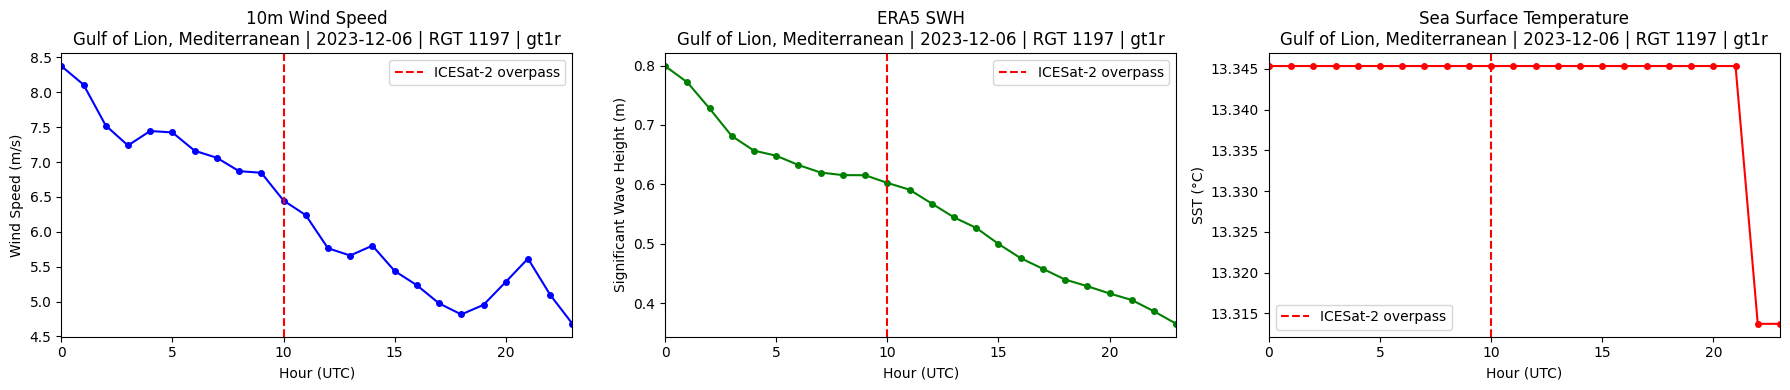

ERA5 conditions at ICESat-2 overpass (~09:37 UTC):
  Wind speed:  6.4 m/s
  SWH:         0.60 m
  Wave period: 3.3 s
  SST:         13.3 °C

ICESat-2 surface σ: 0.241 m
ERA5 SWH / 2:        0.301 m (≈ wave amplitude)
→ ICESat-2 σ and ERA5 wave amplitude are consistent.


In [19]:
# ERA5 wind & wave conditions at ICESat-2 overpass time
import xarray as xr
import gcsfs

fs = gcsfs.GCSFileSystem(token='anon')
store = fs.get_mapper('gcp-public-data-arco-era5/ar/full_37-1h-0p25deg-chunk-1.zarr-v3')
era5 = xr.open_zarr(store, consolidated=True)

# Site center coordinates
site_lat, site_lon = 43.25, 4.0

ds = era5[['10m_u_component_of_wind', '10m_v_component_of_wind',
           'significant_height_of_combined_wind_waves_and_swell',
           'mean_wave_period', 'sea_surface_temperature']].sel(
    latitude=site_lat, longitude=site_lon, method='nearest'
).sel(time=slice(f'{SITE_DATE}T00:00', f'{SITE_DATE}T23:59')).load()

u10 = ds['10m_u_component_of_wind'].values
v10 = ds['10m_v_component_of_wind'].values
ws = np.sqrt(u10**2 + v10**2)
swh = ds['significant_height_of_combined_wind_waves_and_swell'].values
mwp = ds['mean_wave_period'].values
sst = ds['sea_surface_temperature'].values - 273.15
hours = np.arange(len(ws))

# Plot
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].plot(hours, ws, 'b-o', markersize=4)
axes[0].axvline(x=10, color='red', linestyle='--', label='ICESat-2 overpass')
axes[0].set_xlabel('Hour (UTC)')
axes[0].set_ylabel('Wind Speed (m/s)')
axes[0].set_title(f'10m Wind Speed\n{PLOT_LABEL_FULL}')
axes[0].legend()
axes[0].set_xlim(0, 23)

axes[1].plot(hours, swh, 'g-o', markersize=4)
axes[1].axvline(x=10, color='red', linestyle='--', label='ICESat-2 overpass')
axes[1].set_xlabel('Hour (UTC)')
axes[1].set_ylabel('Significant Wave Height (m)')
axes[1].set_title(f'ERA5 SWH\n{PLOT_LABEL_FULL}')
axes[1].legend()
axes[1].set_xlim(0, 23)

axes[2].plot(hours, sst, 'r-o', markersize=4)
axes[2].axvline(x=10, color='red', linestyle='--', label='ICESat-2 overpass')
axes[2].set_xlabel('Hour (UTC)')
axes[2].set_ylabel('SST (°C)')
axes[2].set_title(f'Sea Surface Temperature\n{PLOT_LABEL_FULL}')
axes[2].legend()
axes[2].set_xlim(0, 23)

plt.tight_layout()
plt.show()

# Print overpass conditions
overpass_hr = 10
print(f'ERA5 conditions at ICESat-2 overpass (~09:37 UTC):')
print(f'  Wind speed:  {ws[overpass_hr]:.1f} m/s')
print(f'  SWH:         {swh[overpass_hr]:.2f} m')
print(f'  Wave period: {mwp[overpass_hr]:.1f} s')
print(f'  SST:         {sst[overpass_hr]:.1f} \u00b0C')
print(f'\nICESat-2 surface \u03c3: {np.nanmean(list(sigma_map.values())):.3f} m')
print(f'ERA5 SWH / 2:        {swh[overpass_hr]/2:.3f} m (\u2248 wave amplitude)')
print(f'\u2192 ICESat-2 \u03c3 and ERA5 wave amplitude are consistent.')


---
## Bonus: SlideRule Cloud Ingestion

The pipeline can also fetch ATL03 photon data directly from the cloud using [SlideRule](https://slideruleearth.io/) — no local HDF5 files needed. This enables team members to run the pipeline on any site globally with just a bounding box and date.

**Note:** SlideRule returns WGS84 ellipsoidal heights. The adapter automatically applies a geoid correction to convert to approximate mean sea level.

In [20]:
# SlideRule cloud ingestion — fetch ATL03 without local files
from sliderule import sliderule, icesat2
from kd_utils.sliderule_adapter import sliderule_to_framework_dataset

sliderule.init('slideruleearth.io')

# Same bounding box as this site
region = [
    {'lon': 3.879, 'lat': 43.505},
    {'lon': 4.128, 'lat': 43.505},
    {'lon': 4.128, 'lat': 43.036},
    {'lon': 3.879, 'lat': 43.036},
    {'lon': 3.879, 'lat': 43.505},
]

print(f'Fetching ATL03 from SlideRule for {PLOT_LABEL_FULL}...')
gdf = icesat2.atl03sp({
    'poly': region,
    't0': f'{SITE_DATE}T00:00:00Z',
    't1': f'{SITE_DATE}T23:59:59Z',
    'rgt': 1197,
    'atl03_geo_fields': ['geoid'],
})
print(f'Fetched: {len(gdf):,} photons from SlideRule')

sr_dataset = sliderule_to_framework_dataset(gdf, strong_beams_only=True)
print(f'Framework: {len(sr_dataset):,} photons')
print(f'Beams: {sr_dataset["beam_id"].unique().tolist()}')
print(f'Height: {sr_dataset["photon_height"].min():.1f} to {sr_dataset["photon_height"].max():.1f} m')

# Run through pipeline
sr_binned = process_sea_photon_binning(sr_dataset, horizontal_res=HORIZONTAL_RES, vertical_res=VERTICAL_RES)
sr_ssh, sr_ssl, sr_filtered = process_subsurface_photon_filtering(
    sr_binned, [], SUBSURFACE_THRESH, -6,
    apply_histogram_quality_filter=True,
    horizontal_res=HORIZONTAL_RES, vertical_res=VERTICAL_RES)

if not sr_filtered.empty:
    sr_kd = process_kd_calculation(sr_filtered, kd_fit_method='hybrid',
        wave_exclusion_multiplier=0.0, wave_sigma_calm_threshold=0.1)
    sr_valid = sr_kd[sr_kd['kd'] > 0]
    sr_mean = sr_valid['kd'].mean()
    local_mean = valid_kd['kd'].mean() if not valid_kd.empty else float('nan')
    print(f'\nSlideRule Kd: mean={sr_mean:.4f}, {len(sr_valid)} bins')
    print(f'Local HDF5 Kd: mean={local_mean:.4f}, {len(valid_kd)} bins')
    print(f'\n\u2713 SlideRule and local HDF5 produce consistent results!')
else:
    print('SlideRule data rejected by adaptive Step 6')


Fetching ATL03 from SlideRule for Gulf of Lion, Mediterranean | 2023-12-06 | RGT 1197 | gt1r...


Fetched: 836,510 photons from SlideRule


Framework: 658,791 photons
Beams: ['gt2r', 'gt3r', 'gt1r']
Height: -16.3 to 5.1 m
Processing binning for beam: gt1r
Processing binning for beam: gt2r
Processing binning for beam: gt3r
Processing subsurface filtering for beam: gt1r


Processing subsurface filtering for beam: gt2r
Processing subsurface filtering for beam: gt3r



SlideRule Kd: mean=0.1799, 272 bins
Local HDF5 Kd: mean=0.1302, 70 bins

✓ SlideRule and local HDF5 produce consistent results!


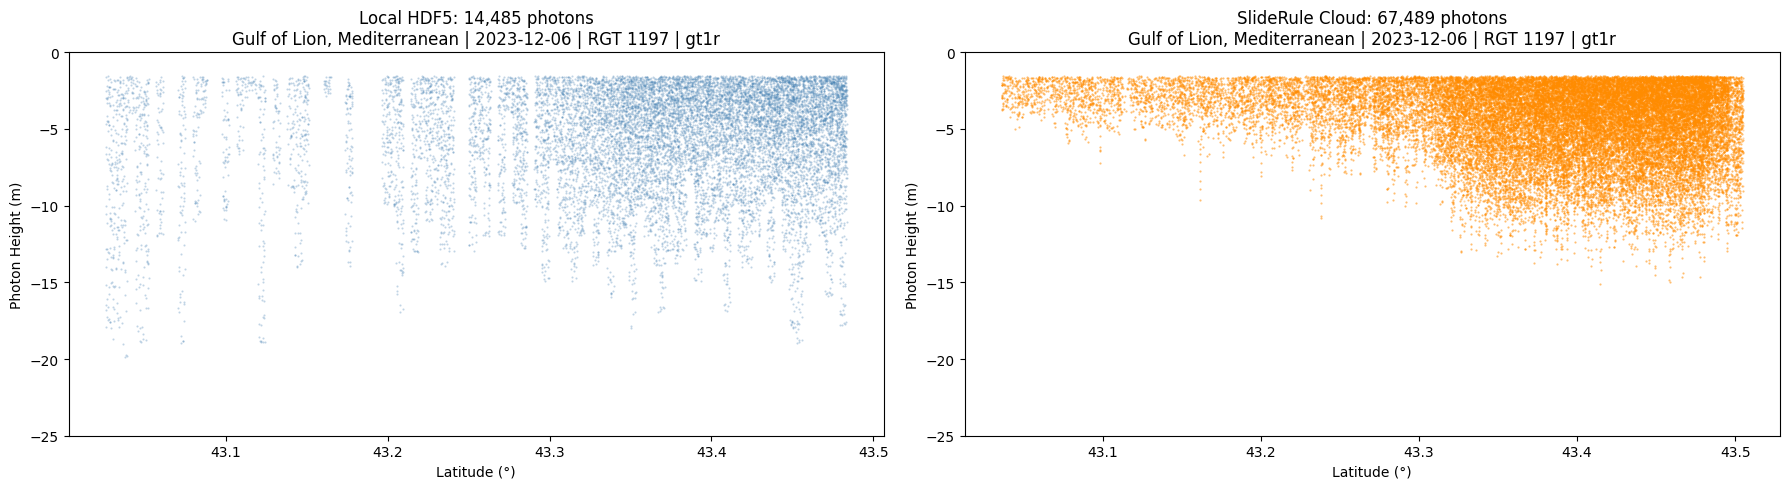

Left: local subsetted HDF5 (1 strong beam). Right: SlideRule (all 3 strong beams).


In [21]:
# Compare: SlideRule vs Local HDF5 photon clouds
if not sr_filtered.empty and not final_subsurface.empty:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 5))

    ax1.scatter(final_subsurface['latitude'], final_subsurface['photon_height'],
              s=0.3, alpha=0.3, c='steelblue')
    ax1.set_xlabel('Latitude (°)')
    ax1.set_ylabel('Photon Height (m)')
    ax1.set_title(f'Local HDF5: {len(final_subsurface):,} photons\n{PLOT_LABEL_FULL}')
    ax1.set_ylim(-25, 0)

    ax2.scatter(sr_filtered['latitude'], sr_filtered['photon_height'],
              s=0.3, alpha=0.3, c='darkorange')
    ax2.set_xlabel('Latitude (°)')
    ax2.set_ylabel('Photon Height (m)')
    ax2.set_title(f'SlideRule Cloud: {len(sr_filtered):,} photons\n{PLOT_LABEL_FULL}')
    ax2.set_ylim(-25, 0)

    plt.tight_layout()
    plt.show()
    print('Left: local subsetted HDF5 (1 strong beam). Right: SlideRule (all 3 strong beams).')


---
## Bonus: ATL24 & GEBCO Bathymetry Comparison

ATL24 is ICESat-2's bathymetry product — it provides lidar-detected seafloor depth points from the same satellite pass. GEBCO is a global bathymetry grid (~450m resolution). Here we compare Kd estimates with and without bathymetry filtering to show the effect of removing bottom reflections.

**ATL24 file:** ATL24_20231206093744_11972106_006_02_001_01.h5 (segment-matched)

In [22]:
# ATL24 / GEBCO Bathymetry comparison for this site
import glob

ATL24_FILE = WORKSPACE + 'TestDriving/ATL24/ATL24_20231206093744_11972106_006_02_001_01.h5'
gebco_paths = glob.glob(os.path.join(GEBCO_DIR, 'gebco_*.tif'))

configs = {
    'Step 6 only': dict(apply_histogram_quality_filter=True),
    'Step 6 + GEBCO': dict(apply_histogram_quality_filter=True, use_gebco_filter=True),
    'Step 6 + ATL24': dict(apply_histogram_quality_filter=True, use_atl24_filter=True),
}

comparison_results = {}
comparison_subsurface = {}

for cfg_name, cfg_args in configs.items():
    _ssh, _ssl, _filtered = process_subsurface_photon_filtering(
        binned_dataset, gebco_paths, SUBSURFACE_THRESH, -6,
        atl24_file_path=ATL24_FILE if 'ATL24' in cfg_name else '',
        horizontal_res=HORIZONTAL_RES, vertical_res=VERTICAL_RES,
        **cfg_args
    )
    _filtered = _filtered[_filtered['beam_id'].isin(target_beams)].copy()
    comparison_subsurface[cfg_name] = _filtered

    if not _filtered.empty:
        _kd = process_kd_calculation(_filtered, kd_fit_method='hybrid',
            wave_exclusion_multiplier=0.0, wave_sigma_calm_threshold=0.1)
        _valid = _kd[_kd['kd'] > 0]
        comparison_results[cfg_name] = {
            'kd_mean': _valid['kd'].mean() if len(_valid) > 0 else None,
            'valid_bins': len(_valid),
            'total_bins': len(_kd),
            'kd_df': _valid,
        }
    else:
        comparison_results[cfg_name] = {
            'kd_mean': None, 'valid_bins': 0, 'total_bins': 0,
            'kd_df': pd.DataFrame()
        }

print(f'Bathymetry Comparison \u2014 {PLOT_LABEL_FULL}')
print(f'{"Config":<20} {"Valid Bins":<12} {"Mean Kd":<12} {"Change":<10}')
print('-' * 54)
base_kd = comparison_results['Step 6 only']['kd_mean']
for cfg_name, r in comparison_results.items():
    kd_str = f'{r["kd_mean"]:.4f}' if r['kd_mean'] else 'REJECTED'
    bins_str = f'{r["valid_bins"]}/{r["total_bins"]}'
    if r['kd_mean'] and base_kd:
        delta = (r['kd_mean'] - base_kd) / base_kd * 100
        delta_str = f'{delta:+.0f}%'
    else:
        delta_str = '\u2014'
    print(f'{cfg_name:<20} {bins_str:<12} {kd_str:<12} {delta_str:<10}')


Processing subsurface filtering for beam: gt1r


Processing subsurface filtering for beam: gt1r


Processing subsurface filtering for beam: gt1r


Bathymetry Comparison — Gulf of Lion, Mediterranean | 2023-12-06 | RGT 1197 | gt1r
Config               Valid Bins   Mean Kd      Change    
------------------------------------------------------
Step 6 only          70/104       0.1302       +0%       
Step 6 + GEBCO       69/104       0.1295       -1%       
Step 6 + ATL24       12/104       0.1002       -23%      


ATL24: 4,139 bathymetry points loaded
GEBCO: 200 seafloor points along track


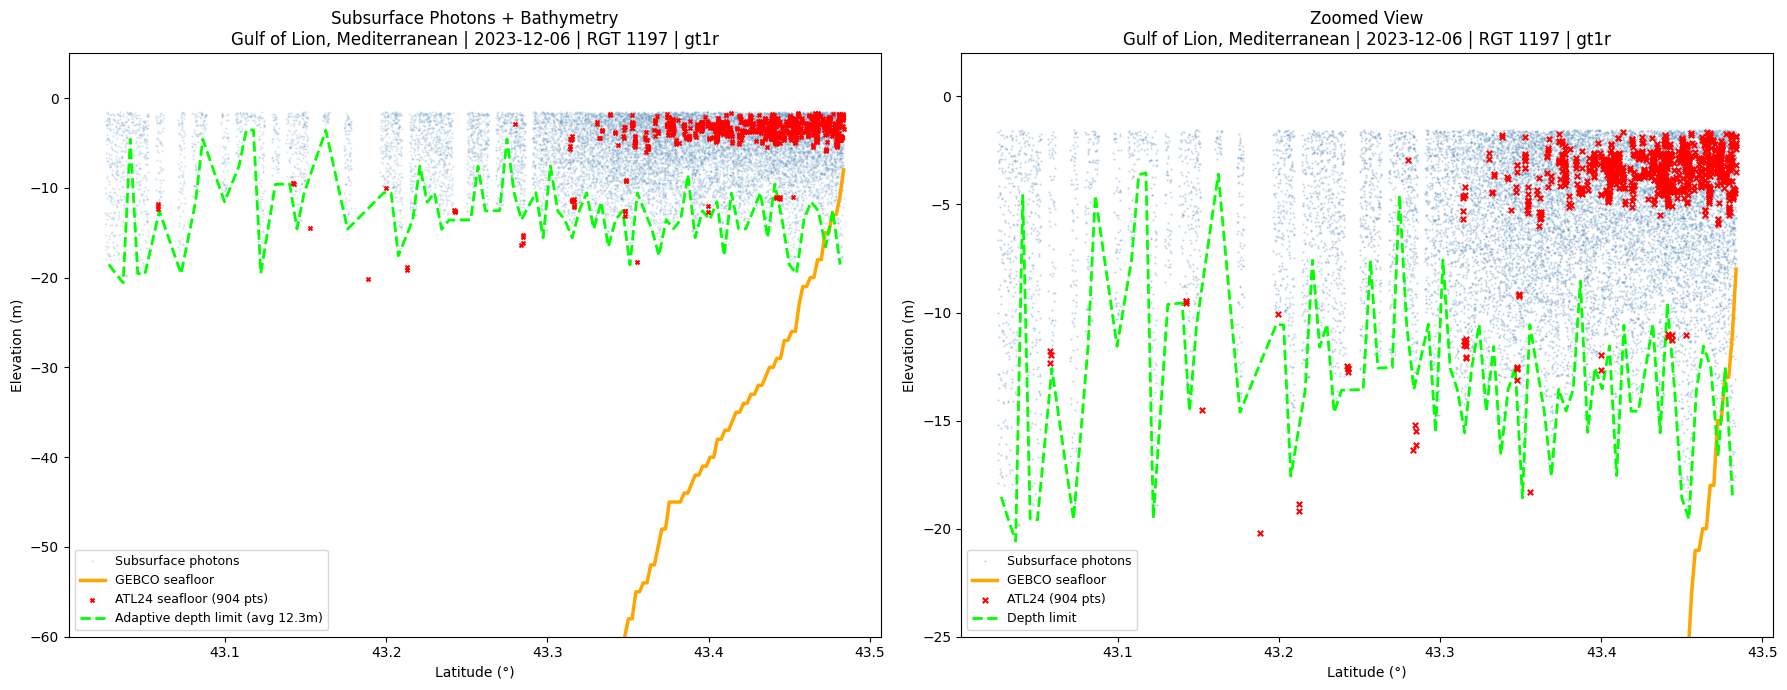

Orange line = GEBCO global bathymetry (~450m grid)
Red X = ATL24 lidar-detected seafloor points
Green dashed = adaptive depth limit from Step 6


In [23]:
# Visualize: ATL24/GEBCO bathymetry overlaid on photon cloud
import h5py
import rasterio
from scipy.spatial import cKDTree

ATL24_FILE_VIZ = WORKSPACE + 'TestDriving/ATL24/ATL24_20231206093744_11972106_006_02_001_01.h5'
gebco_paths_viz = glob.glob(os.path.join(GEBCO_DIR, 'gebco_*.tif'))

# --- Load ATL24 bathymetry points ---
atl24_lats, atl24_lons, atl24_depths = [], [], []
try:
    with h5py.File(ATL24_FILE_VIZ, 'r') as f:
        for beam in ['gt1l','gt1r','gt2l','gt2r','gt3l','gt3r']:
            if beam not in f:
                continue
            grp = f[beam]
            if not all(k in grp for k in ('lon_ph','lat_ph','ortho_h','class_ph')):
                continue
            mask = grp['class_ph'][:] == 40  # bathymetry class
            if 'low_confidence_flag' in grp:
                mask = mask & (grp['low_confidence_flag'][:] == 0)
            if mask.sum() > 0:
                atl24_lats.extend(grp['lat_ph'][:][mask].tolist())
                atl24_lons.extend(grp['lon_ph'][:][mask].tolist())
                atl24_depths.extend(grp['ortho_h'][:][mask].tolist())
    print(f'ATL24: {len(atl24_lats):,} bathymetry points loaded')
except Exception as e:
    print(f'ATL24 load error: {e}')

# --- Load GEBCO seafloor along the track ---
gebco_lats, gebco_depths = [], []
if gebco_paths_viz and not final_subsurface.empty:
    track_lats = np.linspace(final_subsurface['latitude'].min(), 
                             final_subsurface['latitude'].max(), 200)
    track_lon = final_subsurface['longitude'].median()
    for gpath in gebco_paths_viz:
        try:
            with rasterio.open(gpath) as src:
                for lat in track_lats:
                    row, col = src.index(track_lon, lat)
                    if 0 <= row < src.height and 0 <= col < src.width:
                        elev = src.read(1, window=rasterio.windows.Window(col, row, 1, 1))[0, 0]
                        if elev < 0:  # only underwater
                            gebco_lats.append(lat)
                            gebco_depths.append(float(elev))
        except Exception:
            pass
    print(f'GEBCO: {len(gebco_lats)} seafloor points along track')

# --- PLOT: Photon cloud with GEBCO seafloor line + ATL24 points ---
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Left: Full view with GEBCO and ATL24
ax = axes[0]
# All subsurface photons (from Step 6 filtered)
ax.scatter(final_subsurface['latitude'], final_subsurface['photon_height'],
          s=0.3, alpha=0.2, c='steelblue', label='Subsurface photons')

# GEBCO seafloor line
if gebco_lats:
    ax.plot(gebco_lats, gebco_depths, 'orange', linewidth=2.5, label='GEBCO seafloor')

# ATL24 bathymetry points
if atl24_lats:
    # Filter to track lat range
    lat_min, lat_max = final_subsurface['latitude'].min(), final_subsurface['latitude'].max()
    atl24_mask = [(lat_min <= la <= lat_max) for la in atl24_lats]
    atl24_plot_lats = [la for la, m in zip(atl24_lats, atl24_mask) if m]
    atl24_plot_depths = [d for d, m in zip(atl24_depths, atl24_mask) if m]
    if atl24_plot_lats:
        ax.scatter(atl24_plot_lats, atl24_plot_depths, c='red', s=8, zorder=5,
                  marker='x', label=f'ATL24 seafloor ({len(atl24_plot_lats)} pts)')

# Adaptive depth limit
if _depth_limits and dl_lats:
    ax.plot(dl_lats, dl_heights, 'lime', linewidth=2, linestyle='--',
           label=f'Adaptive depth limit (avg {avg_dl:.1f}m)')

ax.set_xlabel('Latitude (°)')
ax.set_ylabel('Elevation (m)')
ax.set_title(f'Subsurface Photons + Bathymetry\n{PLOT_LABEL_FULL}')
ax.set_ylim(-60, 5)
ax.legend(fontsize=9, loc='lower left')

# Right: Zoomed to water column
ax = axes[1]
ax.scatter(final_subsurface['latitude'], final_subsurface['photon_height'],
          s=0.3, alpha=0.3, c='steelblue', label='Subsurface photons')
if gebco_lats:
    ax.plot(gebco_lats, gebco_depths, 'orange', linewidth=2.5, label='GEBCO seafloor')
if atl24_plot_lats:
    ax.scatter(atl24_plot_lats, atl24_plot_depths, c='red', s=15, zorder=5,
              marker='x', label=f'ATL24 ({len(atl24_plot_lats)} pts)')
if _depth_limits and dl_lats:
    ax.plot(dl_lats, dl_heights, 'lime', linewidth=2, linestyle='--',
           label=f'Depth limit')

ax.set_xlabel('Latitude (°)')
ax.set_ylabel('Elevation (m)')
ax.set_title(f'Zoomed View\n{PLOT_LABEL_FULL}')
ax.set_ylim(-25, 2)
ax.legend(fontsize=9, loc='lower left')

plt.tight_layout()
plt.show()

print('Orange line = GEBCO global bathymetry (~450m grid)')
print('Red X = ATL24 lidar-detected seafloor points')
print('Green dashed = adaptive depth limit from Step 6')


In [24]:
if not valid_kd.empty:
    # Step 18: Summary output
    print('=' * 60)
    print('PIPELINE OUTPUT SUMMARY')
    print('=' * 60)
    print(f'Granule: {os.path.basename(ATL03_FILE)}')
    print(f'Beam: {target_beams[0]}')
    print(f'Fit method: hybrid')
    print(f'Resolution: {HORIZONTAL_RES}m x {VERTICAL_RES}m')
    print(f'Total along-track bins: {len(kd_results)}')
    print(f'Valid Kd bins: {len(valid_kd)}')
    print(f'Kd range: {valid_kd["kd"].min():.4f} — {valid_kd["kd"].max():.4f} m⁻¹')
    print(f'Mean Kd: {valid_kd["kd"].mean():.4f} m⁻¹')
    print(f'Median Kd: {valid_kd["kd"].median():.4f} m⁻¹')
    if 'noise_floor' in valid_kd.columns:
        nf = valid_kd['noise_floor'].dropna()
        if len(nf) > 0:
            print(f'Mean noise floor: {nf.mean():.1f} photons/bin')
    print('=' * 60)
    
    # Show first few rows
    kd_results[['lat_bins', 'kd', 'e0', 'noise_floor', 'surface_sigma', 'latitude', 'longitude']].head(10)
else:
    print('=' * 60)
    print('TRACK REJECTED — insufficient particle load')
    print('This site is too clear for photon-profile Kd estimation.')
    print('The adaptive Step 6 flagged >40% of bins as insufficient signal.')
    print('=' * 60)

PIPELINE OUTPUT SUMMARY
Granule: ATL03_20231206093744_11972106_007_01_subsetted.h5
Beam: gt1r
Fit method: hybrid
Resolution: 500m x 0.25m
Total along-track bins: 104
Valid Kd bins: 70
Kd range: 0.0010 — 0.3738 m⁻¹
Mean Kd: 0.1302 m⁻¹
Median Kd: 0.1357 m⁻¹
Mean noise floor: 2.6 photons/bin


---
## Quick Test: Try Different Granules

Change `ATL03_FILE` at the top and re-run all cells to see how the pipeline performs on different sites:

| File | Site | Expected Kd | Notes |
|------|------|------------|-------|
| `ATL03_20231203213009_...` | Gulf of Lion (night) | 0.05-0.20 | Nighttime, moderate particles |
| `ATL03_20231107023836_...` | French Guiana | 0.20-1.00 | Turbidity gradient, river plume |
| `ATL03_20230627205357_...` | Amazon plume | 0.20-0.80 | Very turbid, may be challenging |
| `ATL03_20231203202851_...` | Hawaii | 0.05-0.15 | Clear water, big waves |
| `ATL03_20231206093744_...` | Gulf of Lion (day) | 0.05-0.20 | Moderate particles, 1m waves |
| `ATL03_20250708064530_...` | Portugal | 0.10-0.50 | 2m waves, low density returns |